Datasets: 18
Node MBR (Step 1)       :   56.24% pruned
Leaf MBR (Step 2)       :    2.81% pruned
Per-Series Radial (Step 3):    3.52% pruned
Symbolic Prefix + (Suffix or Residual) (Step 4+5):   34.98% pruned
Exact Distance          :    2.45% pruned
Total                   :  100.00%


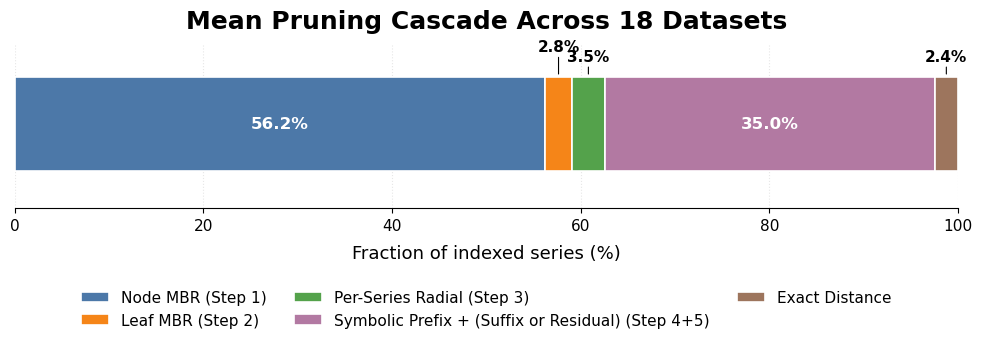

In [40]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

LOG_STAGES = (
    "node MBRs/residual",
    "leaf IVF symbolic",
    "leaf IVF raw ball",
    "record radial",
    "symbolic + residual",
)

PLOT_STAGES = (
    ("Node MBR (Step 1)", "#4C78A8"),
    ("Leaf MBR (Step 2)", "#F58518"),
    ("Per-Series Radial (Step 3)", "#54A24B"),
    ("Symbolic Prefix + (Suffix or Residual) (Step 4+5)", "#B279A2"),
    ("Exact Distance", "#9D755D"),
)


def extract_depth_summary(log_path: Path) -> dict[str, float] | None:
    text = log_path.read_text(errors="replace")
    match = re.search(
        r"^Running dataset=(?P<dataset>\S+).*?method=spartan-depth\s*$"
        r"(?P<body>.*?)(?=^Running dataset=|\Z)",
        text,
        flags=re.MULTILINE | re.DOTALL,
    )
    if not match:
        return None

    body = match.group("body")
    values = {"dataset": match.group("dataset")}
    for log_label in LOG_STAGES:
        line_match = re.search(
            rf"^\s*{re.escape(log_label)}\s*:(?P<line>.*)$",
            body,
            flags=re.MULTILINE,
        )
        if not line_match:
            raise ValueError(f"{log_path}: missing stage {log_label!r}")
        percentages = re.findall(
            r"([0-9]+(?:\.[0-9]+)?)%", line_match.group("line")
        )
        if not percentages:
            raise ValueError(f"{log_path}: no percentage for {log_label!r}")
        # The final percentage is relative to the complete indexed dataset.
        values[log_label] = float(percentages[-1])

    total_match = re.search(
        r"^\s*total\s*:(?P<line>.*records/query.*)$",
        body,
        flags=re.MULTILINE,
    )
    if not total_match:
        raise ValueError(f"{log_path}: missing total pruning line")
    percentages = re.findall(
        r"([0-9]+(?:\.[0-9]+)?)%", total_match.group("line")
    )
    if not percentages:
        raise ValueError(f"{log_path}: invalid total pruning line")
    values["exact"] = max(0.0, 100.0 - float(percentages[-1]))
    return values


def main() -> None:
    candidates = (
        Path("trie_logs/logs_TRIE_64dim_ivf16_ball_avx512_radial_record_parallel_simd-residual-record-only"),
        Path("notebooks/trie_logs/logs_TRIE_64dim_ivf16_ball_avx512_radial_record_parallel_simd-residual-record-only"),
    )
    log_directory = next((path for path in candidates if path.is_dir()), None)
    if log_directory is None:
        checked = "\n".join(f"  - {path.resolve()}" for path in candidates)
        raise FileNotFoundError(f"Log directory not found. Checked:\n{checked}")

    output = Path("images/trie_pruning_breakdown.pdf")
    rows = []
    for log_path in sorted(log_directory.rglob("*.log")):
        row = extract_depth_summary(log_path)
        if row is not None:
            rows.append(row)
    if not rows:
        raise RuntimeError(f"No spartan-depth summaries found in {log_directory}")

    datasets = [row["dataset"] for row in rows]
    if len(datasets) != len(set(datasets)):
        raise RuntimeError("Duplicate spartan-depth summary for a dataset")

    mean = {
        key: np.mean([float(row[key]) for row in rows])
        for key in (*LOG_STAGES, "exact")
    }
    # Merge both group-level filters; symbolic and residual are already merged.
    values = np.array([
        mean["node MBRs/residual"],
        mean["leaf IVF symbolic"] + mean["leaf IVF raw ball"],
        mean["record radial"],
        mean["symbolic + residual"],
        mean["exact"],
    ])
    # Absorb only the small discrepancy caused by two-decimal log rounding.
    values[-1] += 100.0 - values.sum()

    print(f"Datasets: {len(rows)}")
    for (label, _), value in zip(PLOT_STAGES, values):
        action = "evaluated exactly" if label == "Exact distance" else "pruned"
        print(f"{label:24s}: {value:7.2f}% {action}")
    print(f"{'Total':24s}: {values.sum():7.2f}%")

    fig, ax = plt.subplots(figsize=(11.5, 3.4))
    
    left = 0.0
    bar_height = 0.62
    
    for i, ((label, color), value) in enumerate(zip(PLOT_STAGES, values)):
        ax.barh(
            [""],
            [value],
            left=left,
            height=bar_height,
            color=color,
            edgecolor="white",
            linewidth=1.2,
            label=label,
        )
    
        center = left + value / 2
    
        # Large segments: label inside.
        if value >= 5.0:
            ax.text(
                center,
                0,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=12,
                color="white",
                fontweight="bold",
            )
    
        # Small segments: move labels above the bar to avoid overlap.
        elif value >= 1.0:
            ax.annotate(
                f"{value:.1f}%",
                xy=(center, bar_height / 2),
                xytext=(0, 9 + 7 * (i % 2)),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="semibold",
                arrowprops=dict(
                    arrowstyle="-",
                    linewidth=0.8,
                    shrinkA=0,
                    shrinkB=2,
                ),
            )
    
        left += value
    
    
    ax.set_xlim(0, 100)
    ax.set_xlabel(
        "Fraction of indexed series (%)",
        fontsize=13,
        labelpad=8,
    )
    
    # Give annotations more vertical space above the bar.
    ax.set_ylim(-0.55, 0.52)
    
    ax.set_title(
        f"Mean Pruning Cascade Across {len(rows)} Datasets",
        fontsize=18,
        fontweight="semibold",
        pad=12,  # was 12
    )
    
    ax.tick_params(
        axis="x",
        labelsize=11,
    )
    
    ax.tick_params(
        axis="y",
        labelsize=12,
        length=0,
    )
    
    ax.grid(
        axis="x",
        linestyle=":",
        linewidth=0.8,
        alpha=0.3,
    )
    
    ax.set_axisbelow(True)
    
    # Cleaner legend below the plot.
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.42),
        ncol=3,
        frameon=False,
        fontsize=11,
        handlelength=1.8,
        columnspacing=1.8,
    )
    
    # Remove unnecessary borders.
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    
    fig.subplots_adjust(
        left=0.16,
        right=0.98,
        top=0.82,
        bottom=0.34,
    )
    
    fig.savefig(
        output,
        bbox_inches="tight",
        pad_inches=0.03,
    )    
    
    plt.show()


main()
